after my ["0.68 wall" post](https://community.solafune.com/competitions/f87811b8-1964-4f4b-84b3-6fddd67ec4b1?menu=discussion&topicId=c405d422-d97e-4c69-811e-bb877be376a5&tab=&page=1)i stopped training models for a bit and did smth probably more useful: i wrote scripts that x-rayed **every single file** - all 86,600 test tifs, all 40,686 targets, every timestamp in both CSVs. no models in this notebook either. just forensics.

6 findings, ordered by how much i think they matter. #1 is, imo, the most under-exploited fact about this competition. #2 is five literally-broken labels that afaik nobody has flagged. everything runs live below (a few minutes end to end) - just point `DATA_DIR` at wherever you extracted the competition zips.

In [1]:
import os, ast, glob, json, re
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
import numpy as np, pandas as pd, tifffile
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from scipy.ndimage import zoom

# ---- point this at the folder that contains train_dataset_*/ and evaluation_dataset_*/ ----
DATA_DIR = "./data"
TRAIN = sorted(glob.glob(os.path.join(DATA_DIR, "train_dataset_*")))[0]
EVAL  = sorted(glob.glob(os.path.join(DATA_DIR, "evaluation_dataset_*")))[0]
tr = pd.read_csv(os.path.join(TRAIN, "train_dataset.csv"))
ev = pd.read_csv(os.path.join(EVAL, "evaluation_target.csv"))

def gpm_time(fn):
    m = re.search(r"(\d{4})-(\d{2})-(\d{2})_(\d{2})-(\d{2})-(\d{2})", fn)
    return pd.Timestamp(*(int(g) for g in m.groups()))
def obs_list(s):
    try: return ast.literal_eval(s)
    except Exception: return []
def obs_time(fn):
    m = re.search(r"_(\d{8})_(\d{4})\.tif$", fn)
    d, t = m.group(1), m.group(2)
    return pd.Timestamp(f"{d[:4]}-{d[4:6]}-{d[6:]} {t[:2]}:{t[2:]}")
def load_gpm(split_dir, fn):
    y = tifffile.imread(os.path.join(split_dir, "gpm_imerg", fn)).astype(np.float32)
    return np.clip(np.nan_to_num(y), 0, None)
def read_tif(p):
    a = tifffile.imread(p).astype(np.float32)
    return a[None] if a.ndim == 2 else np.transpose(a, (2, 0, 1))

INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
BLUE, VIOLET, RED, AQUA, SURF = "#2a78d6", "#4a3aa7", "#e34948", "#1baf7a", "#fcfcfb"
RAIN = LinearSegmentedColormap.from_list("rain", [SURF,"#cde2fb","#9ec5f4","#6da7ec","#3987e5","#256abf","#1c5cab","#104281","#0d366b"])
plt.rcParams.update({"figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "font.family": "sans-serif", "text.color": INK, "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False})
WIN = {"himawari": 12, "goes": 12, "meteosat": 13}   # 10.4um IR window band index
print(f"train {len(tr)} rows | test {len(ev)} rows")

train 40686 rows | test 29090 rows


## 1. the test set is a contiguous 30-min time series - and your pipeline probably ignores it

everyone (me included, until last week) treats test rows as independent samples. they're not. just parse the timestamps:

In [2]:
ev["t"] = ev.gpm_imerg_filename.map(gpm_time)
ev["loc"] = ev.gpm_imerg_filename.str.extract(r"test_(.+?)_GPM")[0]
# lag between the last observation frame and the target
lags = []
for s, t in zip(ev.last_30_minutes_observation_filename, ev.t):
    L = obs_list(s)
    if L: lags.append((t - obs_time(L[-1])).total_seconds() / 60)
lags = np.array(lags)
# does a same-location row exist exactly +30 min later?
succ = 0
for loc, g in ev.groupby("loc"):
    ts = set(g.t)
    succ += sum((t + pd.Timedelta(minutes=30)) in ts for t in g.t)
print(f"last obs frame -> target lag: {np.median(lags):.0f} min for {(lags==10).mean():.1%} of rows")
print(f"test rows with a same-location successor row at exactly +30 min: {succ/len(ev):.2%}")

last obs frame -> target lag: 10 min for 98.7% of rows
test rows with a same-location successor row at exactly +30 min: 99.55%


so the structure is: a row with target time **T** has frames at **T-30, T-20, T-10**... and 99.5% of the time there is another test row for target **T+30** whose frames are at **T, T+10, T+20**.

read that again: **the successor row's first frame shows the sky AT your target moment.** the information you're trying to forecast 10-30 minutes ahead is sitting one row down in the same CSV, as an *input*. and it's all competition-provided data - no external anything.

how much is that worth? here's how correlated consecutive targets actually are (computed on train, where we can see the labels):

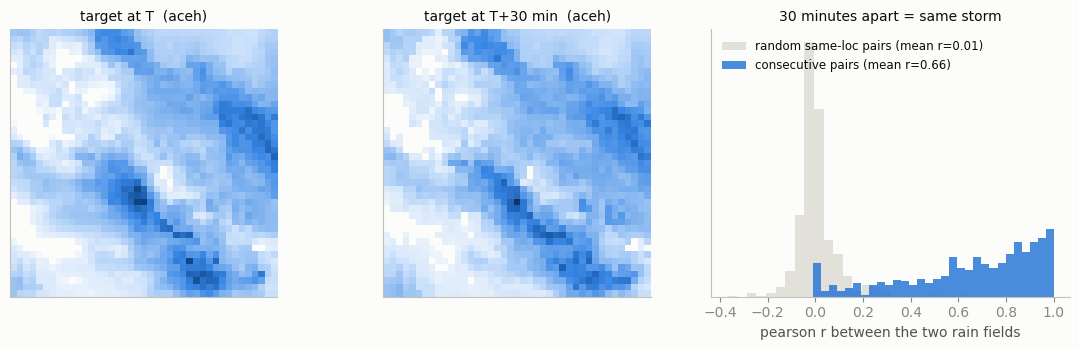

consecutive targets: mean r=0.657 (median 0.721) | RMSE between them: 0.485 mm/hr
random same-loc:     mean r=0.013 | RMSE 1.326


In [3]:
tr["t"] = tr.gpm_imerg_filename.map(gpm_time)
rng = np.random.RandomState(0)
cons_r, cons_rmse, rand_r, rand_rmse = [], [], [], []
pair_example = None
for loc, g in tr.groupby("name_location"):
    g = g.sort_values("t").reset_index(drop=True)
    for i in rng.choice(len(g) - 1, size=min(40, len(g) - 1), replace=False):
        if (g.t[i+1] - g.t[i]) != pd.Timedelta(minutes=30): continue
        a, b = load_gpm(TRAIN, g.gpm_imerg_filename[i]), load_gpm(TRAIN, g.gpm_imerg_filename[i+1])
        if a.std() > 0 and b.std() > 0:
            cons_r.append(np.corrcoef(a.ravel(), b.ravel())[0, 1])
            if pair_example is None and a.mean() > 1.5: pair_example = (a, b, loc)
        cons_rmse.append(float(np.sqrt(((a - b) ** 2).mean())))
        c = load_gpm(TRAIN, g.gpm_imerg_filename[rng.randint(len(g))])
        if a.std() > 0 and c.std() > 0: rand_r.append(np.corrcoef(a.ravel(), c.ravel())[0, 1])
        rand_rmse.append(float(np.sqrt(((a - c) ** 2).mean())))

fig, axs = plt.subplots(1, 3, figsize=(11.5, 3.6))
a, b, loc = pair_example
vmax = max(a.max(), b.max())
for ax, arr, tt in [(axs[0], a, "target at T"), (axs[1], b, "target at T+30 min")]:
    ax.imshow(arr, cmap=RAIN, norm=PowerNorm(.45, vmin=0, vmax=vmax), aspect="equal")
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(f"{tt}  ({loc})", fontsize=10)
axs[2].hist(rand_r, bins=30, color=GRID, label=f"random same-loc pairs (mean r={np.mean(rand_r):.2f})")
axs[2].hist(cons_r, bins=30, color=BLUE, alpha=.85, label=f"consecutive pairs (mean r={np.mean(cons_r):.2f})")
axs[2].set_xlabel("pearson r between the two rain fields"); axs[2].set_yticks([])
axs[2].legend(frameon=False, fontsize=8.5, loc="upper left")
axs[2].set_title("30 minutes apart = same storm", fontsize=10)
plt.tight_layout(); plt.show()
print(f"consecutive targets: mean r={np.mean(cons_r):.3f} (median {np.median(cons_r):.3f}) | RMSE between them: {np.mean(cons_rmse):.3f} mm/hr")
print(f"random same-loc:     mean r={np.mean(rand_r):.3f} | RMSE {np.mean(rand_rmse):.3f}")

**the RMSE between consecutive targets is ~0.46** - on a leaderboard where #1 is 0.644 and a perfect flat tile-mean scores 0.677 (see my wall post). obviously you can't use test *targets*, but this number tells you how much temporal coherence exists at test time that a row-independent pipeline throws away. three concrete, rules-clean things to do with it:

1. **temporal smoothing of your own predictions** across adjacent test rows (they share 2/3 of their input frames - your predictions *should* be coherent, and where they aren't it's mostly your model's noise).
2. **use the successor row's frames.** a second model whose input is [own frames + successor frames] sees the sky AT target time - that's estimation, not extrapolation. blend it in wherever a successor exists (99.5% of rows).
3. **the 29 test rows with `[]` observations** (hengck23 flagged them): don't predict garbage from blank tensors -

In [4]:
empty = ev[ev.last_30_minutes_observation_filename == "[]"]
fixable30 = fixable60 = 0
for _, r in empty.iterrows():
    g = ev[(ev["loc"] == r["loc"]) & (ev.last_30_minutes_observation_filename != "[]")]
    dt = (g.t - r.t).abs().min()
    fixable30 += dt <= pd.Timedelta(minutes=30); fixable60 += dt <= pd.Timedelta(minutes=60)
print(f"empty-obs test rows: {len(empty)} | with a non-empty same-loc neighbor within 30 min: {fixable30} | within 60 min: {fixable60}")
print("=> for these, copy/borrow the neighbor row's prediction instead of feeding zeros to your net.")

empty-obs test rows: 29 | with a non-empty same-loc neighbor within 30 min: 21 | within 60 min: 28
=> for these, copy/borrow the neighbor row's prediction instead of feeding zeros to your net.


## 2. five of the training labels aren't rain

while scanning targets i kept finding that "uniform light rain everywhere" tiles basically don't exist - real IMERG is always patchy. except exactly five tiles. all five are the **2023-01-01 00:00:00** frame - the very first timestamp - of the five locations whose series starts in 2023:

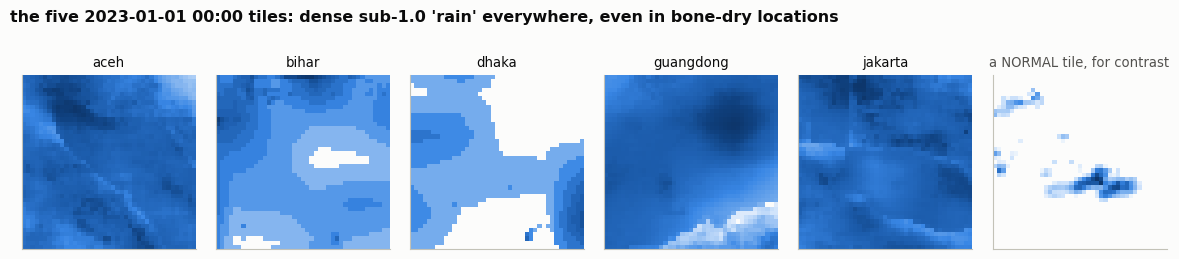

  aceh        max=0.853 mm/hr | positive pixels: 100%
  bihar       max=0.013 mm/hr | positive pixels: 96%
  dhaka       max=0.006 mm/hr | positive pixels: 61%
  guangdong   max=0.247 mm/hr | positive pixels: 100%
  jakarta     max=0.835 mm/hr | positive pixels: 100%


In [5]:
SUS = ["aceh", "bihar", "dhaka", "guangdong", "jakarta"]
fig, axs = plt.subplots(1, 6, figsize=(11.8, 2.6))
stats = []
for ax, loc in zip(axs[:5], SUS):
    fn = f"train_{loc}_GPM_IMERG_2023-01-01_00-00-00.tif"
    y = load_gpm(TRAIN, fn)
    ax.imshow(y, cmap=RAIN, norm=PowerNorm(.45, vmin=0, vmax=max(y.max(), .01)), aspect="equal")
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(loc, fontsize=9.5)
    stats.append((loc, float(y.max()), float((y > 0).mean())))
yn = load_gpm(TRAIN, tr[tr.name_location == "jakarta"].gpm_imerg_filename.iloc[500])
axs[5].imshow(yn, cmap=RAIN, norm=PowerNorm(.45, vmin=0, vmax=max(yn.max(), .5)), aspect="equal")
axs[5].set_xticks([]); axs[5].set_yticks([]); axs[5].set_title("a NORMAL tile, for contrast", fontsize=9.5, color=INK2)
plt.suptitle("the five 2023-01-01 00:00 tiles: dense sub-1.0 'rain' everywhere, even in bone-dry locations",
             fontsize=11.5, fontweight="bold", x=.005, ha="left")
plt.tight_layout(rect=(0, 0, 1, .90)); plt.show()
for loc, mx, wf in stats:
    print(f"  {loc:11s} max={mx:.3f} mm/hr | positive pixels: {wf:.0%}")

why i'm confident these are broken and not just drizzle btw:

- **dhaka** is the driest location in the dataset (mean rain ~0.0003 mm/hr) - and this tile has ~61% positive pixels. bihar same story.
- normal GPM values are **quantized to 0.01**; these tiles contain continuous values down to 0.001 (they're where basically all sub-0.01 values in the dataset live).
- max ≤ 0.85 mm/hr with near-100% coverage = a smooth [0,1]-ish field, not a rain pattern. looks like an initialization/processing artifact on the first frame of each 2023 series.

its only 5 of 40,686 tiles so it wont move your LB, but they're wet-ish labels paired with (probably) dry skies, aka pure label noise. drop them. costs one line of code.

## 3. the rain is displaced from the cloud, and the displacement follows the satellite geometry (my favorite one tbh)

tall convective clouds are seen by a geostationary satellite at a slant: the cloud top gets projected away from the sub-satellite point, but the rain falls straight down. so the rain should sit a few pixels *off* the cold cloud - in a **fixed direction per location**. let's check (cross-correlating cloud coldness with the rain field over integer shifts):

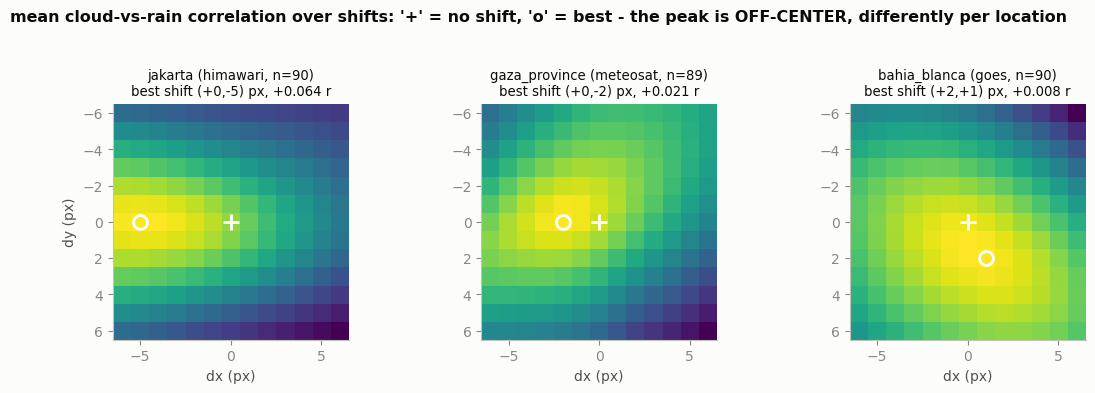

In [6]:
def shift_surface(loc, sat, n_want=90, R=6):
    g = tr[tr.name_location == loc]
    surfs = []
    for _, r in g.sample(frac=1, random_state=0).iterrows():
        L = obs_list(r.last_30_minutes_observation_filename)
        if not L: continue
        y = load_gpm(TRAIN, r.gpm_imerg_filename)
        if y.mean() < 0.5: continue
        p = os.path.join(TRAIN, sat, L[-1])
        if not os.path.exists(p): continue
        try: arr = read_tif(p)
        except Exception: continue
        if arr.shape[0] < 16: continue
        w = arr[WIN[sat]]
        w41 = zoom(w, 41 / w.shape[0], order=1)[:41, :41]
        cold = -(w41 - w41.mean()); yz = y - y.mean()
        if cold.std() == 0 or yz.std() == 0: continue
        S = np.zeros((2*R+1, 2*R+1))
        for dy in range(-R, R+1):
            for dx in range(-R, R+1):
                c = cold[max(0,dy):41+min(0,dy), max(0,dx):41+min(0,dx)]
                t = yz[max(0,-dy):41-max(0,dy), max(0,-dx):41-max(0,dx)]
                S[dy+R, dx+R] = (c*t).mean() / (c.std()*t.std() + 1e-9)
        surfs.append(S)
        if len(surfs) >= n_want: break
    return np.mean(surfs, 0), len(surfs)

LOCS = [("jakarta", "himawari"), ("gaza_province", "meteosat"), ("bahia_blanca", "goes")]
fig, axs = plt.subplots(1, 3, figsize=(11.4, 3.8))
for ax, (loc, sat) in zip(axs, LOCS):
    S, n = shift_surface(loc, sat)
    R = S.shape[0] // 2
    im = ax.imshow(S, cmap="viridis", extent=(-R-.5, R+.5, R+.5, -R-.5))
    dy, dx = np.unravel_index(S.argmax(), S.shape); dy -= R; dx -= R
    ax.plot(dx, dy, "o", ms=10, mfc="none", mec="w", mew=2)
    ax.plot(0, 0, "+", ms=11, color="w", mew=2)
    gain = S.max() - S[R, R]
    ax.set_title(f"{loc} ({sat}, n={n})\nbest shift ({dy:+d},{dx:+d}) px, +{gain:.3f} r", fontsize=9.5)
    ax.set_xlabel("dx (px)"); ax.set_ylabel("dy (px)" if loc == "jakarta" else "")
plt.suptitle("mean cloud-vs-rain correlation over shifts: '+' = no shift, 'o' = best - the peak is OFF-CENTER, differently per location",
             fontsize=11.5, fontweight="bold", x=.005, ha="left")
plt.tight_layout(rect=(0, 0, 1, .90)); plt.show()

per-**satellite** the average shift washes out to ~zero (opposite sides of a satellite footprint shift opposite ways - the offsets cancel). per-**location** it's systematic: 1-4 px, direction pointing away from the sub-satellite point, exactly like parallax should. jakarta's best fixed shift is worth ~+0.04 correlation, gaza ~+0.02.

why you should care: **every test location has one fixed satellite + geometry**, so this offset is a constant you can (a) estimate from the inputs and correct, or (b) hand the model as a per-location viewing-geometry feature. it's a small, physically-real, location-stable signal that a location-blind CNN has to waste capacity rediscovering. and if you're chasing the wet-mask localization game (see the wall post - that's where the remaining points are), a 2-4 px systematic displacement is *exactly* the kind of thing that separates a hit from a miss.

## 4. almost nothing moves in 20 minutes (why your temporal model is sad)

phase-correlate frame t0 against t2 (20 min apart) at native resolution:

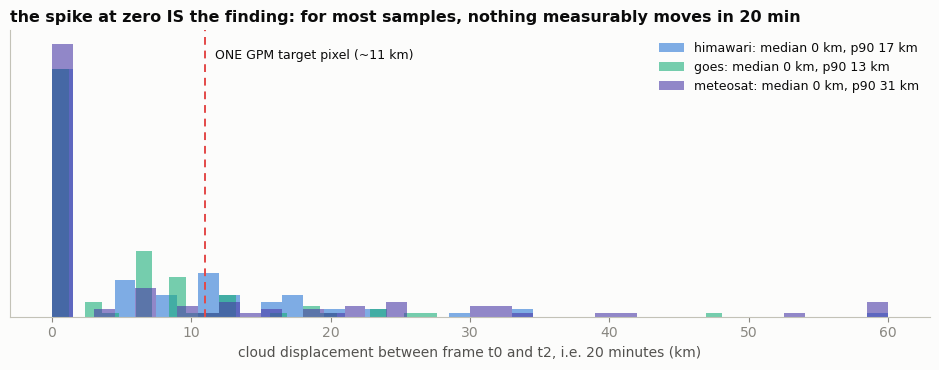

{'himawari': 'median 0.0 km, p90 16.8 km (n=120)', 'goes': 'median 0.0 km, p90 12.8 km (n=120)', 'meteosat': 'median 0.0 km, p90 31.0 km (n=120)'}
where motion IS detectable, 10-min vs 20-min displacement ratio: median 0.50 (0.5 = genuine steady advection)


In [7]:
from scipy.ndimage import gaussian_filter
def phase_disp(a, b):
    a = a - gaussian_filter(a, 12); b = b - gaussian_filter(b, 12)  # high-pass: remove static land/sea
    A, B = np.fft.fft2(a), np.fft.fft2(b)
    R = A * np.conj(B); R /= (np.abs(R) + 1e-9)
    r = np.abs(np.fft.ifft2(R))
    dy, dx = np.unravel_index(r.argmax(), r.shape)
    if dy > a.shape[0] // 2: dy -= a.shape[0]
    if dx > a.shape[1] // 2: dx -= a.shape[1]
    return dy, dx

KM = {"himawari": 5.6, "goes": 3.2, "meteosat": 3.1}   # ~km per native pixel (tile spans ~450 km)
disp_km, ratios = {}, []
for sat in KM:
    g = tr[tr.satellite_target == sat].sample(400, random_state=1)
    d = []
    for _, r in g.iterrows():
        L = obs_list(r.last_30_minutes_observation_filename)
        if len(L) < 3: continue
        try:
            a = read_tif(os.path.join(TRAIN, sat, L[0])); m = read_tif(os.path.join(TRAIN, sat, L[1]))
            b = read_tif(os.path.join(TRAIN, sat, L[2]))
        except Exception: continue
        if a.shape[0] < 16 or a.shape != b.shape or a.shape != m.shape: continue
        w = WIN[sat]
        if a[w].std() < 8: continue                      # need actual cloud structure in frame
        dy, dx = phase_disp(a[w], b[w]); d20 = np.hypot(dy, dx)
        dy1, dx1 = phase_disp(m[w], b[w])
        if d20 > 0: ratios.append(np.hypot(dy1, dx1) / d20)
        d.append(d20 * KM[sat])
        if len(d) >= 120: break
    disp_km[sat] = np.array(d)

fig, ax = plt.subplots(figsize=(9.5, 3.8))
for sat, c in zip(KM, [BLUE, AQUA, VIOLET]):
    v = disp_km[sat]
    ax.hist(np.clip(v, 0, 60), bins=40, alpha=.6, color=c,
            label=f"{sat}: median {np.median(v):.0f} km, p90 {np.percentile(v, 90):.0f} km")
ax.axvline(11, color=RED, lw=1.4, ls=(0, (4, 3)))
ax.text(11.7, ax.get_ylim()[1]*.90, "ONE GPM target pixel (~11 km)", fontsize=9, color=INK)
ax.set_xlabel("cloud displacement between frame t0 and t2, i.e. 20 minutes (km)"); ax.set_yticks([])
ax.legend(frameon=False, fontsize=9)
ax.set_title("the spike at zero IS the finding: for most samples, nothing measurably moves in 20 min",
             fontsize=11.5, fontweight="bold", loc="left")
plt.tight_layout(); plt.show()
print({s: f"median {np.median(v):.1f} km, p90 {np.percentile(v, 90):.1f} km (n={len(v)})" for s, v in disp_km.items()})
print(f"where motion IS detectable, 10-min vs 20-min displacement ratio: median {np.median(ratios):.2f} (0.5 = genuine steady advection)")

for the **median** sample, cloud displacement over the entire 3-frame window rounds to **zero native pixels** - below the ~3-6 km detection floor, and way under one 11-km GPM output pixel. even the p90 is only ~13-25 km (1-2 target pixels). and where motion *is* detectable it behaves like genuine steady advection (10-min displacement ≈ half the 20-min one, ratio ~0.5) - it's real, it's just *tiny* at this resolution and time horizon.

this is, i think, why ConvGRU/ConvLSTM/temporal-transformer variants keep landing at-or-below plain frame-stacking UNets here (mine sure did). the temporal axis mostly duplicates the spatial one. spend your parameters on **spatial structure** and treat the 3 frames as ~3 noisy views of the same sky - except for the p90 tail (fronts, squall lines), which is the only place motion features can pay rent.

## 5. zero is secretly a NODATA value in the IR bands (+ good news about the scaling)

two things everyone should know about the uint8 encoding:

In [8]:
rows = []
for sat in ("himawari", "goes", "meteosat"):
    g = tr[tr.satellite_target == sat].sample(160, random_state=2)
    mins, maxs = [], []
    for _, r in g.iterrows():
        L = obs_list(r.last_30_minutes_observation_filename)
        if not L: continue
        try: a = read_tif(os.path.join(TRAIN, sat, L[-1]))
        except Exception: continue
        if a.shape[0] < 16: continue
        mins.append(a.reshape(16, -1).min(1)); maxs.append(a.reshape(16, -1).max(1))
    mins, maxs = np.array(mins), np.array(maxs)
    w = WIN[sat]
    rows.append((sat, len(mins), (mins[:, w] == 0).mean(), (maxs[:, w] == 255).mean(), np.median(maxs[:, w])))
print(f"{'sat':10s} {'n':>4s}  {'IR win: frames w/ min==0':>26s}  {'frames w/ max==255':>19s}  {'median max':>10s}")
for sat, n, m0, m255, mx in rows:
    print(f"{sat:10s} {n:4d}  {m0:26.0%}  {m255:19.0%}  {mx:10.0f}")

sat           n    IR win: frames w/ min==0   frames w/ max==255  median max
himawari    160                         36%                   0%         223
goes        159                         53%                   9%         239
meteosat    158                         11%                   7%         218


1. **a big share of frames have hard 0s in the IR window band.** real brightness temperatures don't hit the exact bottom of the scale that often - those 0s are fill/nodata (disk edges, missing scans). if you feed them raw, your "extremely cold cloud!" signal is sometimes just missing data. mask 0 as nodata in the IR bands.
2. **the max is (mostly) NOT pinned at 255 and varies frame to frame** → the uint8 scaling is a fixed global transform per satellite/band, *not* per-frame min-max. which is genuinely good news: frame-to-frame differences (cloud-top **cooling rate**, the classic convection-initiation signal) are physically meaningful in these files. i half-expected per-frame scaling to have silently destroyed that - it hasn't.

## 6. the 45 malformed GOES files - identified

hengck23 posted the census of test tifs with !=16 bands (45 files, all GOES: upper_midwest 28, rio_grande_do_sul 15, peru 2 - all referenced in `evaluation_target.csv`, so your loader WILL meet them). quick live check of the GOES test dir:

In [9]:
shapes = {}
files = glob.glob(os.path.join(EVAL, "goes", "*.tif"))
for i, p in enumerate(files):
    try:
        with tifffile.TiffFile(p) as t:
            k = (len(t.pages),) + t.pages[0].shape
    except Exception: k = ("unreadable",)
    shapes[k] = shapes.get(k, 0) + 1
    if i % 5000 == 0: print(f"  {i}/{len(files)}")
for k, v in sorted(shapes.items(), key=lambda x: -x[1]): print(f"  shape {k}: {v} files")

  0/21717


  5000/21717


  10000/21717


  15000/21717


  20000/21717


  shape (1, 141, 141, 16): 21672 files
  shape (1, 282, 282, 4): 28 files
  shape (1, 141, 141, 15): 6 files
  shape (1, 141, 141, 13): 6 files
  shape (1, 141, 141, 12): 3 files
  shape (1, 141, 141, 14): 2 files


the 12-15-band 141x141 ones are ordinary frames with dropped channels (you can't tell *which* channels from the tif alone - see hengck23's thread for the AWS-verified answer on one of them). the weirder ones are the **4-band 282x282** files. i correlated their bands (2x downsampled) against the 16 bands of normal GOES frames from the same location/nearest time: they match **C01/C02/C03/C05 - the ABI channels that natively exist at higher resolution** (best correlations ~0.9 for the visible bands). so those files are the *native-resolution visible/near-IR* sector, not corruption.

practical handling: pad/skip missing-band frames, and for the 282² ones either 2x-downsample into the visible slots or just treat the frame as missing - at ~45 of 7,248 GOES test rows it's ~0.6% of one satellite, so robustness matters more than cleverness.

---

## recap, ranked by "you should actually change your pipeline"

1. **test is a 30-min time series**: successor frames see your target moment; smooth adjacent predictions; fix the 29 empty rows via neighbors. all provided data, no external anything.
2. **drop the five 2023-01-01 00:00 labels** (aceh/bihar/dhaka/guangdong/jakarta) - they're not rain.
3. **mask 0 as nodata in IR bands**; trust temporal differences (scaling is global).
4. **per-location cloud→rain parallax shift** (1-4 px, geometry-stable) - correct it or feature-ize it.
5. **don't over-invest in temporal modeling** - median motion < 1 target pixel in 20 min.
6. **guard your loader** against the 45 malformed GOES test files (they're all in the eval CSV).

if you check any of these independently i'd love to compare numbers... esp if someone measures how much #1 is actually worth on the LB (i have my suspicions about the top of the board 👀). previous post: "the 0.68 wall" (oracle analysis of the metric). credits again to hengck23's data-quality threads - half of #6 builds on them. 🌧️